In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl
from itertools import combinations
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from IPython.display import display

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42



df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/interaction_type_bout.csv')
df1['Condition'] = 'GH Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/interaction_type_bout.csv')
df2['Condition'] = 'GH Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/interaction_type_bout.csv')
df3['Condition'] = 'GH Starved-Starved'


df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/interaction_type_bout.csv')
df4['Condition'] = 'SI Fed-Fed'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/interaction_type_bout.csv')
df5['Condition'] = 'SI Fed-Starved'

df6 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/interaction_type_bout.csv')
df6['Condition'] = 'SI Starved-Starved'


df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)

df = df[df['start_frame'] < 1200].copy()



si = df[df['Condition'].str.contains('SI')].copy()
gh = df[df['Condition'].str.contains('GH')].copy()



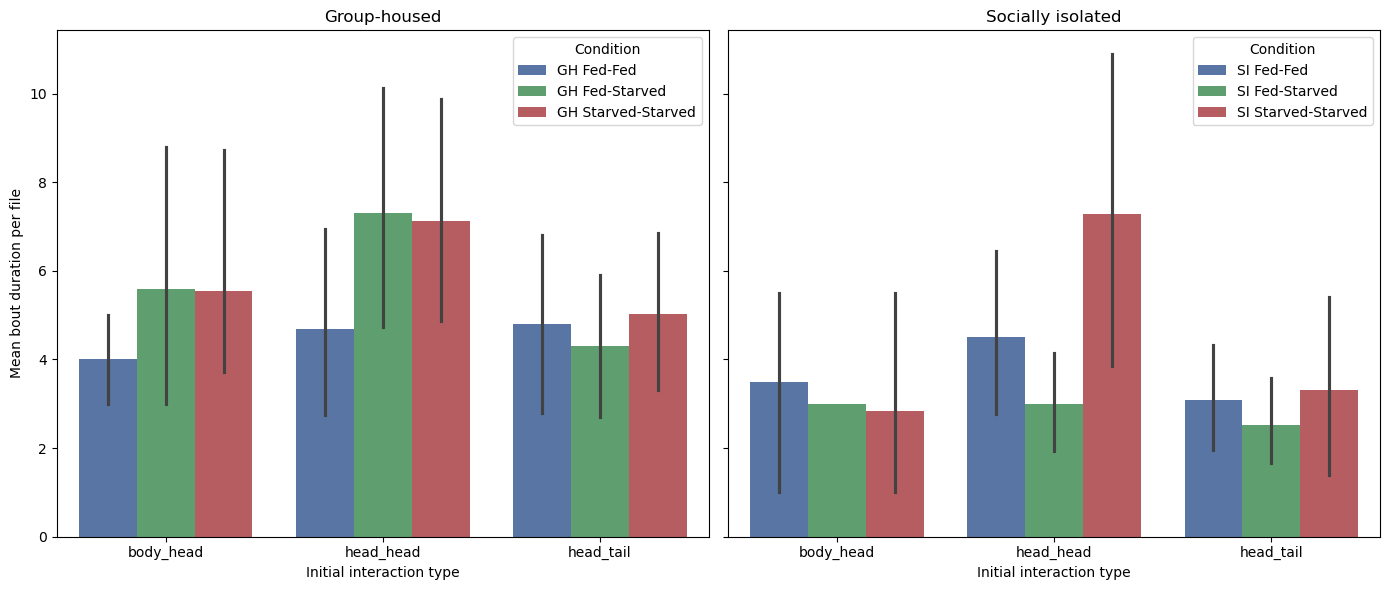

In [2]:

# Mean duration per file
plot_df = (
    df.groupby(["Condition", "file", "initial_type"], as_index=False)["duration"]
      .mean()
)

gh = plot_df[plot_df["Condition"].str.contains("GH")].copy()
si = plot_df[plot_df["Condition"].str.contains("SI")].copy()

order = sorted(plot_df["initial_type"].unique())

gh_order = ["GH Fed-Fed", "GH Fed-Starved", "GH Starved-Starved"]
si_order = ["SI Fed-Fed", "SI Fed-Starved", "SI Starved-Starved"]

palette_gh = {
    "GH Fed-Fed": "#4C72B0",
    "GH Fed-Starved": "#55A868",
    "GH Starved-Starved": "#C44E52",
}

palette_si = {
    "SI Fed-Fed": "#4C72B0",
    "SI Fed-Starved": "#55A868",
    "SI Starved-Starved": "#C44E52",
}

fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

# ---------------- GH ----------------
sns.barplot(
    data=gh,
    x="initial_type",
    y="duration",
    hue="Condition",
    order=order,
    hue_order=gh_order,
    palette=palette_gh,

    ax=axes[0]
)

axes[0].set_title("Group-housed")
axes[0].set_xlabel("Initial interaction type")
axes[0].set_ylabel("Mean bout duration per file")


# ---------------- SI ----------------
sns.barplot(
    data=si,
    x="initial_type",
    y="duration",
    hue="Condition",
    order=order,
    hue_order=si_order,
    palette=palette_si,
    ax=axes[1]
)



axes[1].set_title("Socially isolated")
axes[1].set_xlabel("Initial interaction type")
axes[1].set_ylabel("")


plt.tight_layout()
plt.show()



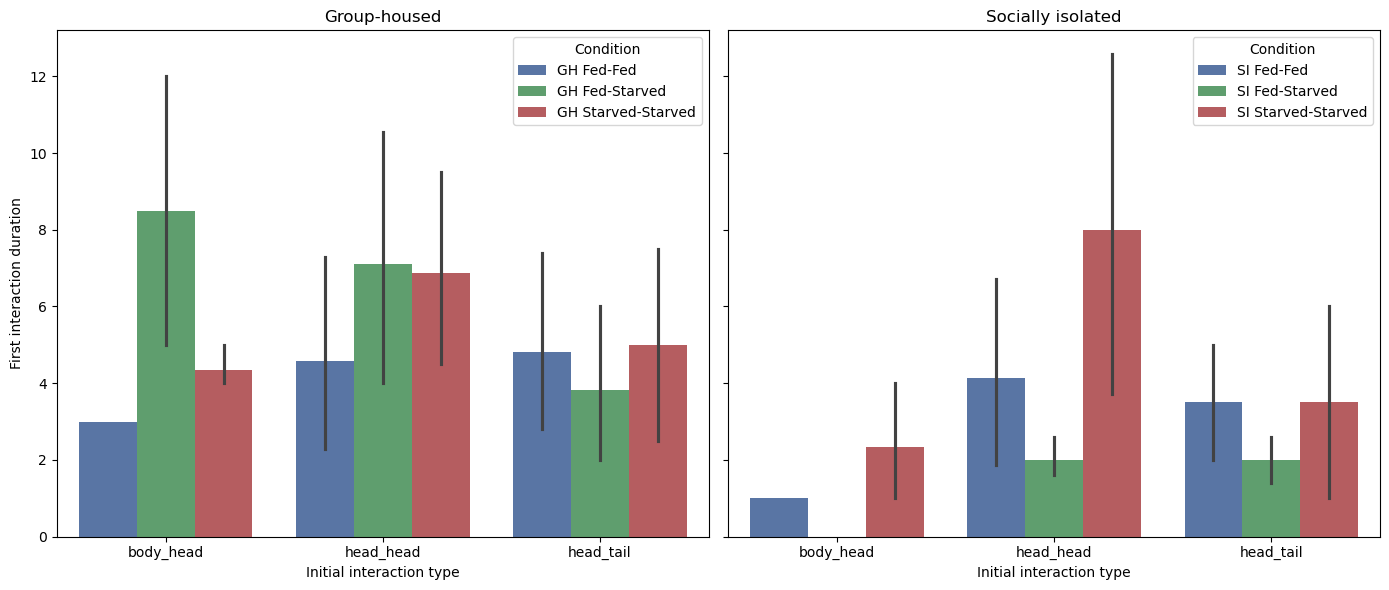

In [3]:
si = df[df["Condition"].str.contains("SI")].copy()
gh = df[df["Condition"].str.contains("GH")].copy()

si = si.sort_values(["Condition", "file", "start_frame"])
gh = gh.sort_values(["Condition", "file", "start_frame"])


si['interaction_number'] = (
    si.groupby(['Condition', 'file']).cumcount() + 1
)

gh['interaction_number'] = (
    gh.groupby(['Condition', 'file']).cumcount() + 1
)

# Keep only the first interaction in each file
gh_first = gh[gh['interaction_number'] == 1].copy()
si_first = si[si['interaction_number'] == 1].copy()

# Combine back together
plot_df = pd.concat([gh_first, si_first], ignore_index=True)

order = sorted(plot_df["initial_type"].unique())

gh_order = ["GH Fed-Fed", "GH Fed-Starved", "GH Starved-Starved"]
si_order = ["SI Fed-Fed", "SI Fed-Starved", "SI Starved-Starved"]

palette_gh = {
    "GH Fed-Fed": "#4C72B0",
    "GH Fed-Starved": "#55A868",
    "GH Starved-Starved": "#C44E52",
}

palette_si = {
    "SI Fed-Fed": "#4C72B0",
    "SI Fed-Starved": "#55A868",
    "SI Starved-Starved": "#C44E52",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------------- GH ----------------
sns.barplot(
    data=gh_first,
    x="initial_type",
    y="duration",
    hue="Condition",
    order=order,
    hue_order=gh_order,
    palette=palette_gh,
    ax=axes[0]
)

axes[0].set_title("Group-housed")
axes[0].set_xlabel("Initial interaction type")
axes[0].set_ylabel("First interaction duration")

# ---------------- SI ----------------
sns.barplot(
    data=si_first,
    x="initial_type",
    y="duration",
    hue="Condition",
    order=order,
    hue_order=si_order,
    palette=palette_si,
    ax=axes[1]
)

axes[1].set_title("Socially isolated")
axes[1].set_xlabel("Initial interaction type")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

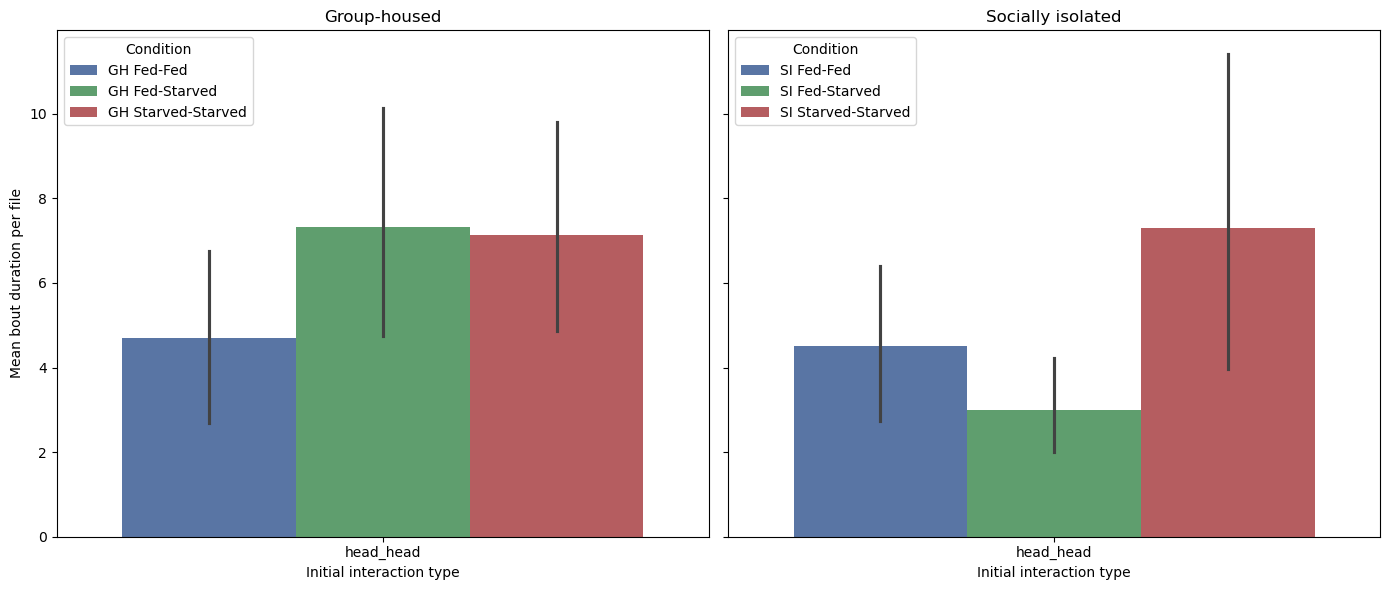

In [4]:
df = df[df["initial_type"] == "head_head"]

# Mean duration per file
plot_df = (
    df.groupby(["Condition", "file", "initial_type"], as_index=False)["duration"]
      .mean()
)

gh = plot_df[plot_df["Condition"].str.contains("GH")].copy()
si = plot_df[plot_df["Condition"].str.contains("SI")].copy()

order = sorted(plot_df["initial_type"].unique())

gh_order = ["GH Fed-Fed", "GH Fed-Starved", "GH Starved-Starved"]
si_order = ["SI Fed-Fed", "SI Fed-Starved", "SI Starved-Starved"]

palette_gh = {
    "GH Fed-Fed": "#4C72B0",
    "GH Fed-Starved": "#55A868",
    "GH Starved-Starved": "#C44E52",
}

palette_si = {
    "SI Fed-Fed": "#4C72B0",
    "SI Fed-Starved": "#55A868",
    "SI Starved-Starved": "#C44E52",
}

fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

# ---------------- GH ----------------
sns.barplot(
    data=gh,
    x="initial_type",
    y="duration",
    hue="Condition",
    order=order,
    hue_order=gh_order,
    palette=palette_gh,

    ax=axes[0]
)

axes[0].set_title("Group-housed")
axes[0].set_xlabel("Initial interaction type")
axes[0].set_ylabel("Mean bout duration per file")


# ---------------- SI ----------------
sns.barplot(
    data=si,
    x="initial_type",
    y="duration",
    hue="Condition",
    order=order,
    hue_order=si_order,
    palette=palette_si,
    ax=axes[1]
)



axes[1].set_title("Socially isolated")
axes[1].set_xlabel("Initial interaction type")
axes[1].set_ylabel("")


plt.tight_layout()
plt.show()



In [5]:
from scipy.stats import mannwhitneyu
import pandas as pd


def stats_table(data, condition_order, group_name):

    print(f"\n========== {group_name} ==========\n")

    # ---------- Mann-Whitney U ----------
    pairwise = []

    comparisons = [
        (condition_order[0], condition_order[1]),
        (condition_order[1], condition_order[2]),
    ]

    for cond1, cond2 in comparisons:

        g1 = data.loc[data["Condition"] == cond1, "duration"].dropna()
        g2 = data.loc[data["Condition"] == cond2, "duration"].dropna()

        U, p = mannwhitneyu(g1, g2, alternative="two-sided")

        pairwise.append({
            "Group":group_name,
            "Comparison":f"{cond1} vs {cond2}",
            "n1":len(g1),
            "n2":len(g2),
            "U":U,
            "p-value":p
        })

    pairwise = pd.DataFrame(pairwise)

    def stars(p):
        if p < 0.001:
            return "***"
        elif p < 0.01:
            return "**"
        elif p < 0.05:
            return "*"
        return ""

    pairwise["Significance"] = pairwise["p-value"].apply(stars)

    display(pairwise)

    return pairwise



gh_pairwise = stats_table(
    gh,
    gh_order,
    "Group-housed"
)

si_pairwise = stats_table(
    si,
    si_order,
    "Socially isolated"
)


========== Group-housed ==========



,Group,Comparison,n1,n2,U,p-value,Significance
0,Group-housed,GH Fed-Fed vs GH Fed-Starved,8,11,29.5,0.246221,
1,Group-housed,GH Fed-Starved vs GH Starved-Starved,11,8,44.5,1.000000,



========== Socially isolated ==========



,Group,Comparison,n1,n2,U,p-value,Significance
0,Socially isolated,SI Fed-Fed vs SI Fed-Starved,9,7,40.5,0.363635,
1,Socially isolated,SI Fed-Starved vs SI Starved-Starved,7,9,17.0,0.135162,


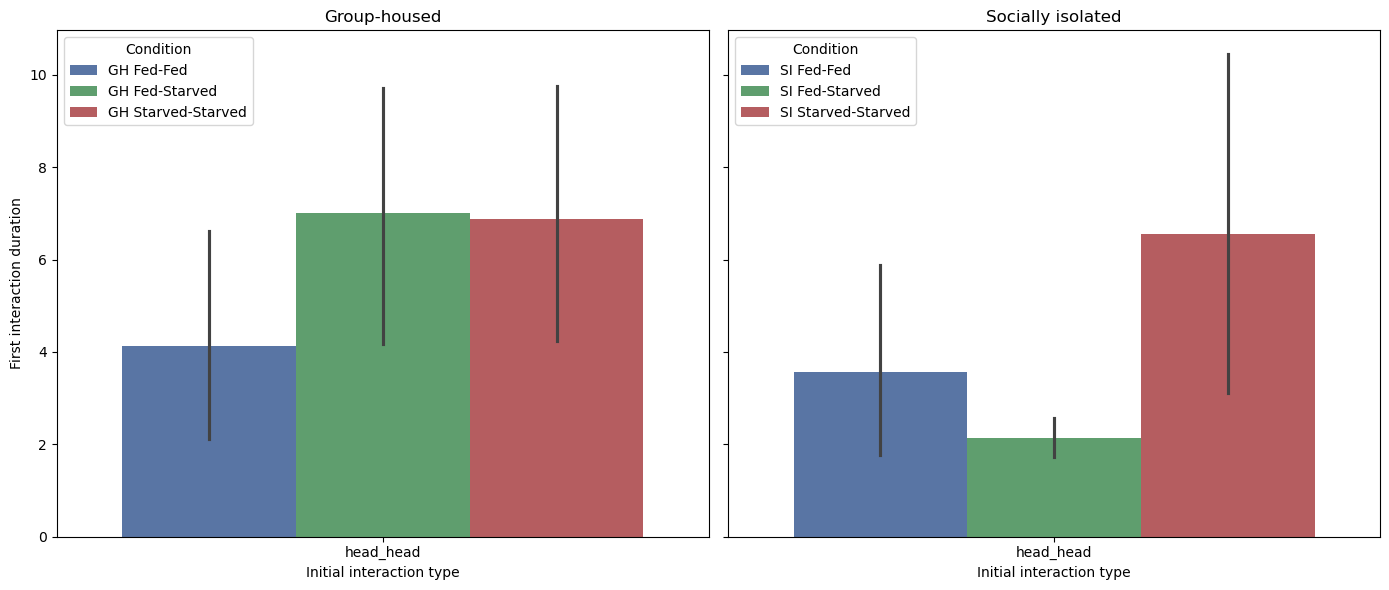

In [6]:
df = df[df["initial_type"] == "head_head"]


si = df[df["Condition"].str.contains("SI")].copy()
gh = df[df["Condition"].str.contains("GH")].copy()

si = si.sort_values(["Condition", "file", "start_frame"])
gh = gh.sort_values(["Condition", "file", "start_frame"])


si['interaction_number'] = (
    si.groupby(['Condition', 'file']).cumcount() + 1
)

gh['interaction_number'] = (
    gh.groupby(['Condition', 'file']).cumcount() + 1
)

# Keep only the first interaction in each file
gh_first = gh[gh['interaction_number'] == 1].copy()
si_first = si[si['interaction_number'] == 1].copy()

# Combine back together
plot_df = pd.concat([gh_first, si_first], ignore_index=True)

order = sorted(plot_df["initial_type"].unique())

gh_order = ["GH Fed-Fed", "GH Fed-Starved", "GH Starved-Starved"]
si_order = ["SI Fed-Fed", "SI Fed-Starved", "SI Starved-Starved"]

palette_gh = {
    "GH Fed-Fed": "#4C72B0",
    "GH Fed-Starved": "#55A868",
    "GH Starved-Starved": "#C44E52",
}

palette_si = {
    "SI Fed-Fed": "#4C72B0",
    "SI Fed-Starved": "#55A868",
    "SI Starved-Starved": "#C44E52",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------------- GH ----------------
sns.barplot(
    data=gh_first,
    x="initial_type",
    y="duration",
    hue="Condition",
    order=order,
    hue_order=gh_order,
    palette=palette_gh,
    ax=axes[0]
)

axes[0].set_title("Group-housed")
axes[0].set_xlabel("Initial interaction type")
axes[0].set_ylabel("First interaction duration")

# ---------------- SI ----------------
sns.barplot(
    data=si_first,
    x="initial_type",
    y="duration",
    hue="Condition",
    order=order,
    hue_order=si_order,
    palette=palette_si,
    ax=axes[1]
)

axes[1].set_title("Socially isolated")
axes[1].set_xlabel("Initial interaction type")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [7]:
from scipy.stats import mannwhitneyu
import pandas as pd


def stats_table(data, condition_order, group_name):

    print(f"\n========== {group_name} ==========\n")

    # ---------- Mann-Whitney U ----------
    pairwise = []

    comparisons = [
        (condition_order[0], condition_order[1]),
        (condition_order[1], condition_order[2]),
    ]

    for cond1, cond2 in comparisons:

        g1 = data.loc[data["Condition"] == cond1, "duration"].dropna()
        g2 = data.loc[data["Condition"] == cond2, "duration"].dropna()

        U, p = mannwhitneyu(g1, g2, alternative="two-sided")

        pairwise.append({
            "Group":group_name,
            "Comparison":f"{cond1} vs {cond2}",
            "n1":len(g1),
            "n2":len(g2),
            "U":U,
            "p-value":p
        })

    pairwise = pd.DataFrame(pairwise)

    def stars(p):
        if p < 0.001:
            return "***"
        elif p < 0.01:
            return "**"
        elif p < 0.05:
            return "*"
        return ""

    pairwise["Significance"] = pairwise["p-value"].apply(stars)

    display(pairwise)

    return pairwise



gh_pairwise = stats_table(
    gh,
    gh_order,
    "Group-housed"
)

si_pairwise = stats_table(
    si,
    si_order,
    "Socially isolated"
)




========== Group-housed ==========



,Group,Comparison,n1,n2,U,p-value,Significance
0,Group-housed,GH Fed-Fed vs GH Fed-Starved,10,16,56.0,0.213699,
1,Group-housed,GH Fed-Starved vs GH Starved-Starved,16,11,89.0,0.980219,



========== Socially isolated ==========



,Group,Comparison,n1,n2,U,p-value,Significance
0,Socially isolated,SI Fed-Fed vs SI Fed-Starved,15,11,76.5,0.769150,
1,Socially isolated,SI Fed-Starved vs SI Starved-Starved,11,13,40.0,0.070132,
